In [57]:
# 1. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

# Thiết lập hiển thị
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Đọc dữ liệu từ file CSV
df = pd.read_csv('DTS_IncmTaxRfnd_20200613_20250612.csv')

# Kiểm tra thông tin cơ bản của dữ liệu
print("THÔNG TIN CƠ BẢN VỀ DỮ LIỆU")
print("=" * 50)
print(f"Kích thước dữ liệu: {df.shape}")
print(f"Các cột trong dữ liệu: {list(df.columns)}")
print(f"\nMẫu dữ liệu đầu tiên:")
print(df.head())

THÔNG TIN CƠ BẢN VỀ DỮ LIỆU
Kích thước dữ liệu: (6526, 15)
Các cột trong dữ liệu: ['Record Date', 'Federal Tax Refund Type', 'Federal Tax Refunds Today', 'Federal Tax Refunds Month to Date', 'Federal Tax Refunds Fiscal Year to Date', 'Table Number', 'Table Name', 'Sub Table Name', 'Source Line Number', 'Fiscal Year', 'Fiscal Quarter Number', 'Calendar Year', 'Calendar Quarter Number', 'Calendar Month Number', 'Calendar Day Number']

Mẫu dữ liệu đầu tiên:
  Record Date                  Federal Tax Refund Type  \
0  2025-06-12    Taxes - Business Tax Refunds (Checks)   
1  2025-06-12       Taxes - Business Tax Refunds (EFT)   
2  2025-06-12  Taxes - Individual Tax Refunds (Checks)   
3  2025-06-12     Taxes - Individual Tax Refunds (EFT)   
4  2025-06-11    Taxes - Business Tax Refunds (Checks)   

   Federal Tax Refunds Today  Federal Tax Refunds Month to Date  \
0                        103                               7337   
1                         -2                              

In [113]:
#2 Mô Tả và Khai Phá Dữ Liệu (Describe & Mining)
# Chuyển đổi cột ngày thành định dạng datetime
df['Record Date'] = pd.to_datetime(df['Record Date'])

# Định nghĩa các loại hoàn thuế chính
main_refund_types = [
    'Taxes - Business Tax Refunds (Checks)',
    'Taxes - Business Tax Refunds (EFT)',
    'Taxes - Individual Tax Refunds (Checks)',
    'Taxes - Individual Tax Refunds (EFT)'
]

# Lọc dữ liệu theo các loại hoàn thuế chính
df_filtered = df[df['Federal Tax Refund Type'].isin(main_refund_types)].copy()

# Tạo pivot table theo ngày và loại hoàn thuế
daily_pivot = df_filtered.pivot_table(
    index='Record Date',
    columns='Federal Tax Refund Type',
    values='Federal Tax Refunds Today',
    aggfunc='sum',
    fill_value=0
)

# Tính tổng hoàn thuế hàng ngày
daily_pivot['Total'] = daily_pivot.sum(axis=1)

# Tạo dữ liệu hàng tháng
monthly_pivot = daily_pivot.resample('ME').sum()
print(f"\n✓ Đã xử lý dữ liệu thành công")
print(f"Số ngày có dữ liệu: {len(daily_pivot)}")
print(f"Số tháng có dữ liệu: {len(monthly_pivot)}")
print(f"Khoảng thời gian: {daily_pivot.index.min()} đến {daily_pivot.index.max()}")


✓ Đã xử lý dữ liệu thành công
Số ngày có dữ liệu: 585
Số tháng có dữ liệu: 29
Khoảng thời gian: 2023-02-14 00:00:00 đến 2025-06-12 00:00:00


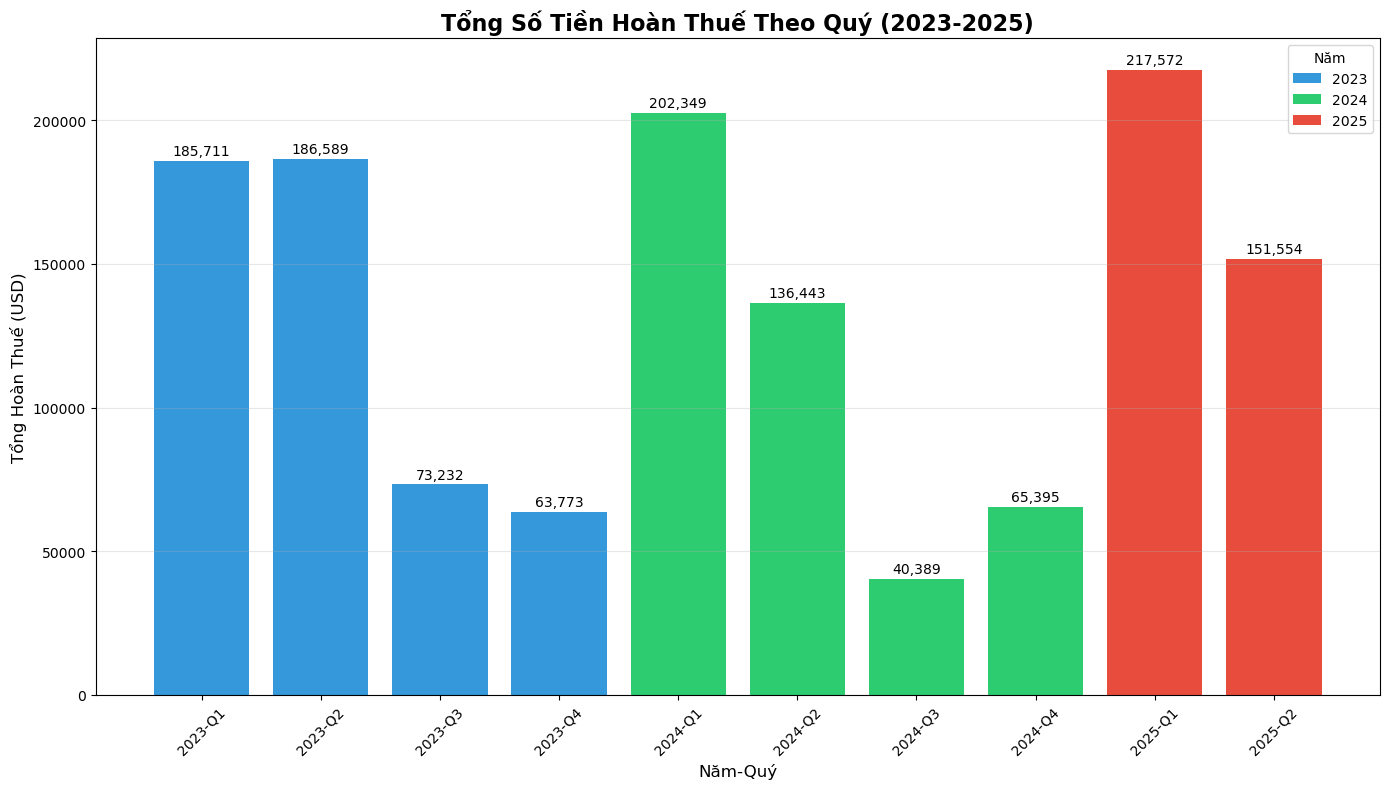

In [61]:
# Tạo biểu đồ cột thể hiện tổng số tiền hoàn thuế theo quý
# Thêm thông tin năm và quý vào dữ liệu hàng tháng
monthly_pivot_2023_2025 = monthly_pivot[monthly_pivot.index >= '2023-01-01']
monthly_pivot_2023_2025['Year'] = monthly_pivot_2023_2025.index.year
monthly_pivot_2023_2025['Quarter'] = monthly_pivot_2023_2025.index.quarter

# Tạo pivot table theo quý
quarterly_pivot = monthly_pivot_2023_2025.groupby(['Year', 'Quarter'])['Total'].sum().reset_index()

# Tạo cột Year-Quarter để hiển thị trên trục x
quarterly_pivot['Year-Quarter'] = quarterly_pivot['Year'].astype(str) + '-Q' + quarterly_pivot['Quarter'].astype(str)

# Tạo bảng màu cho từng năm
colors = {'2023': '#3498db', '2024': '#2ecc71', '2025': '#e74c3c'}
bar_colors = [colors[str(year)] for year in quarterly_pivot['Year']]

# Vẽ biểu đồ cột
plt.figure(figsize=(14, 8))
bars = plt.bar(quarterly_pivot['Year-Quarter'], quarterly_pivot['Total'], color=bar_colors)

# Thêm nhãn giá trị trên đỉnh mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# Thêm tiêu đề và nhãn trục
plt.title('Tổng Số Tiền Hoàn Thuế Theo Quý (2023-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Năm-Quý', fontsize=12)
plt.ylabel('Tổng Hoàn Thuế (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Thêm chú thích màu cho từng năm
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[str(year)], label=str(year)) for year in sorted(quarterly_pivot['Year'].unique())]
plt.legend(handles=legend_elements, title='Năm')

plt.tight_layout()
plt.savefig('quarterly_refund_total.png', dpi=300)
plt.show()

In [62]:
# Tính toán các thống kê mô tả cơ bản
print("PHÂN TÍCH MÔ TẢ THỐNG KÊ")
print("=" * 50)

total_refunds = daily_pivot['Total'].sum()
average_monthly = monthly_pivot['Total'].mean()
max_monthly = monthly_pivot['Total'].max()
min_monthly = monthly_pivot['Total'].min()

print(f"Tổng số tiền hoàn thuế: ${total_refunds:,.2f}")
print(f"Mức hoàn thuế trung bình hàng tháng: ${average_monthly:,.2f}")
print(f"Mức hoàn thuế cao nhất trong tháng: ${max_monthly:,.2f}")
print(f"Mức hoàn thuế thấp nhất trong tháng: ${min_monthly:,.2f}")

PHÂN TÍCH MÔ TẢ THỐNG KÊ
Tổng số tiền hoàn thuế: $1,323,007.00
Mức hoàn thuế trung bình hàng tháng: $45,620.93
Mức hoàn thuế cao nhất trong tháng: $116,859.00
Mức hoàn thuế thấp nhất trong tháng: $7,217.00


In [63]:
# Phân tích theo loại hoàn thuế
print("\nPhân tích theo loại hoàn thuế:")
for col in main_refund_types:
    total_by_type = monthly_pivot[col].sum()
    percentage = (total_by_type / total_refunds) * 100
    print(f"{col}: ${total_by_type:,.2f} ({percentage:.2f}%)")


Phân tích theo loại hoàn thuế:
Taxes - Business Tax Refunds (Checks): $277,689.00 (20.99%)
Taxes - Business Tax Refunds (EFT): $44,351.00 (3.35%)
Taxes - Individual Tax Refunds (Checks): $154,672.00 (11.69%)
Taxes - Individual Tax Refunds (EFT): $846,295.00 (63.97%)


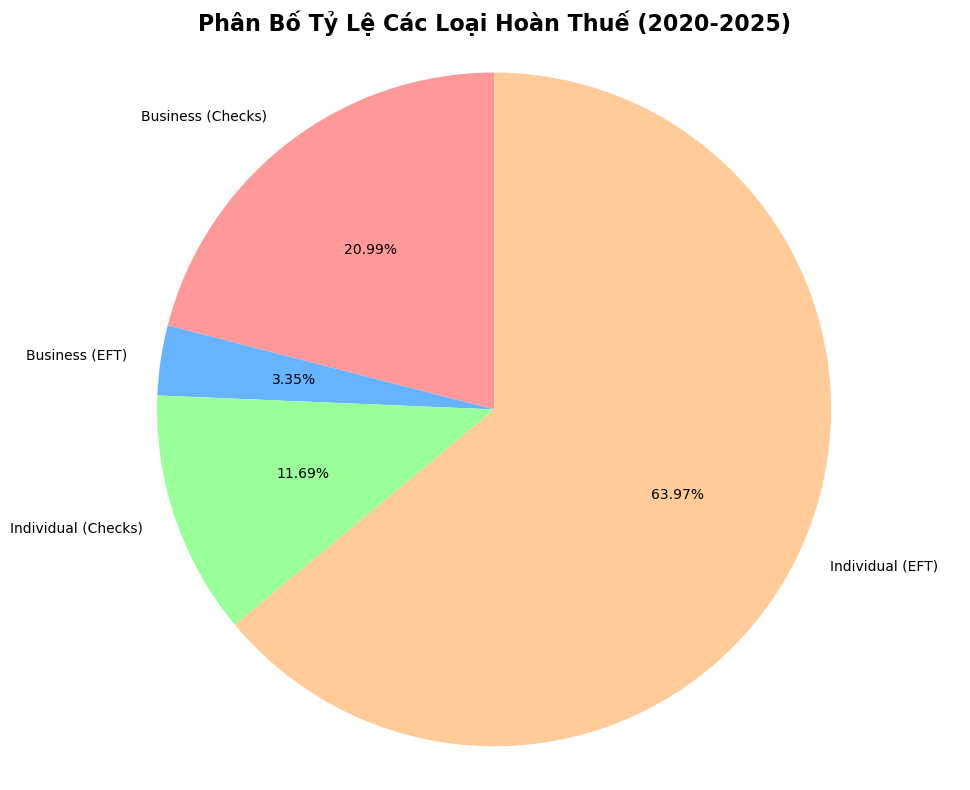

In [64]:
# Tính toán dữ liệu cho biểu đồ tròn
refund_totals = []
labels = []
for col in main_refund_types:
    total = monthly_pivot[col].sum()
    refund_totals.append(total)
    labels.append(col.replace('Taxes - ', '').replace(' Tax Refunds', ''))

# Vẽ biểu đồ tròn
plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(refund_totals, labels=labels, autopct='%1.2f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 10})
plt.title('Phân Bố Tỷ Lệ Các Loại Hoàn Thuế (2020-2025)', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [65]:
#3 Phân Tích Chi Tiết (Analysis)
# Phân rã chuỗi thời gian
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

print("PHÂN TÍCH CHUỖI THỜI GIAN")
print("=" * 50)

ts_data = monthly_pivot['Total']
decomposition = seasonal_decompose(
    ts_data, 
    model='additive', 
    period=12,
    extrapolate_trend='freq'
)

# Tính toán tỷ lệ phương sai
seasonal_var = decomposition.seasonal.var()
trend_var = decomposition.trend.var()
resid_var = decomposition.resid.dropna().var()
total_var = seasonal_var + trend_var + resid_var

print(f"Thành phần mùa vụ: {(seasonal_var/total_var)*100:.2f}%")
print(f"Thành phần xu hướng: {(trend_var/total_var)*100:.2f}%")
print(f"Thành phần dư: {(resid_var/total_var)*100:.2f}%")

PHÂN TÍCH CHUỖI THỜI GIAN
Thành phần mùa vụ: 94.01%
Thành phần xu hướng: 1.15%
Thành phần dư: 4.84%


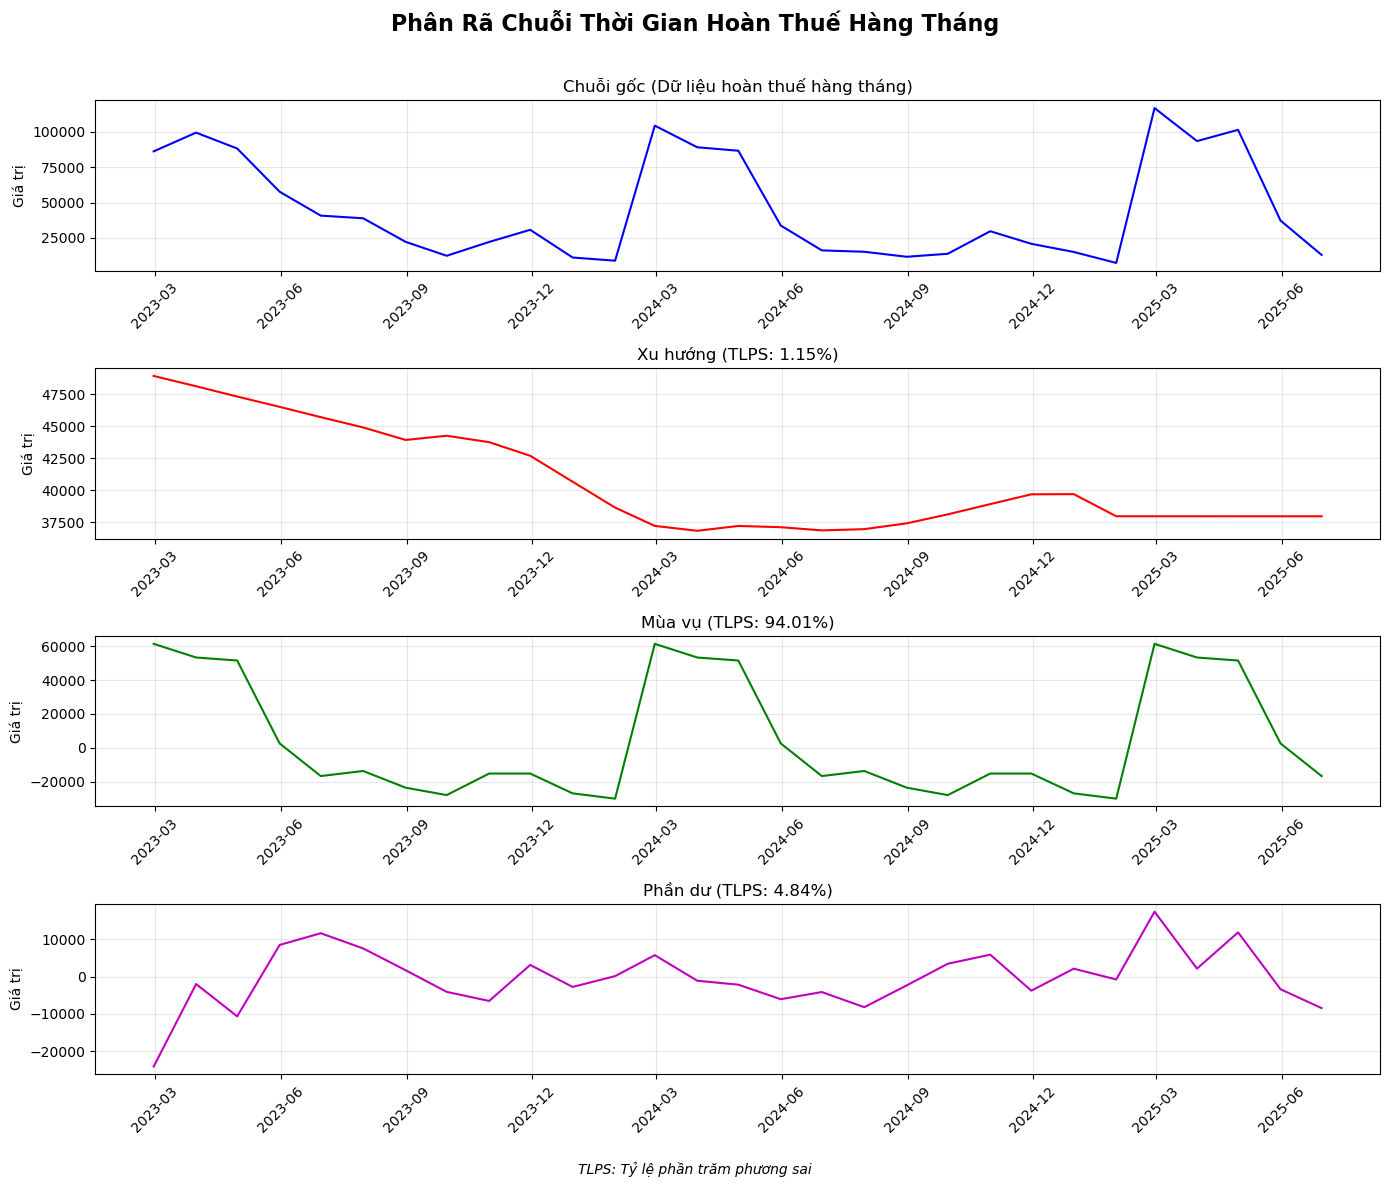

In [66]:
# Tạo biểu đồ phân rã chuỗi thời gian
from statsmodels.tsa.seasonal import seasonal_decompose

# Sử dụng dữ liệu tổng hoàn thuế hàng tháng
ts_data = monthly_pivot['Total']

# Thực hiện phân rã chuỗi thời gian
decomposition = seasonal_decompose(
    ts_data, 
    model='additive', 
    period=12,
    extrapolate_trend='freq'
)

# Tính toán tỷ lệ phương sai
seasonal_var = decomposition.seasonal.var()
trend_var = decomposition.trend.var()
resid_var = decomposition.resid.dropna().var()
total_var = seasonal_var + trend_var + resid_var

seasonal_pct = (seasonal_var/total_var)*100
trend_pct = (trend_var/total_var)*100
resid_pct = (resid_var/total_var)*100

# Vẽ biểu đồ phân rã
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))

# Chuỗi gốc
ax1.plot(ts_data.index, ts_data.values, 'b-', label='Chuỗi gốc')
ax1.set_title(f'Chuỗi gốc (Dữ liệu hoàn thuế hàng tháng)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Xu hướng
ax2.plot(decomposition.trend.index, decomposition.trend.values, 'r-', label='Xu hướng')
ax2.set_title(f'Xu hướng (TLPS: {trend_pct:.2f}%)', fontsize=12)
ax2.grid(True, alpha=0.3)

# Mùa vụ
ax3.plot(decomposition.seasonal.index, decomposition.seasonal.values, 'g-', label='Mùa vụ')
ax3.set_title(f'Mùa vụ (TLPS: {seasonal_pct:.2f}%)', fontsize=12)
ax3.grid(True, alpha=0.3)

# Phần dư
ax4.plot(decomposition.resid.index, decomposition.resid.values, 'm-', label='Phần dư')
ax4.set_title(f'Phần dư (TLPS: {resid_pct:.2f}%)', fontsize=12)
ax4.grid(True, alpha=0.3)

# Định dạng trục x để hiển thị tháng-năm
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Hiển thị mỗi 3 tháng
    ax.set_ylabel('Giá trị', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

# Thêm tiêu đề chính
plt.suptitle('Phân Rã Chuỗi Thời Gian Hoàn Thuế Hàng Tháng', fontsize=16, fontweight='bold')

# Thêm chú thích về tỷ lệ phương sai
plt.figtext(0.5, 0.01, f'TLPS: Tỷ lệ phần trăm phương sai', 
            ha='center', fontsize=10, fontstyle='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('time_series_decomposition.png', dpi=300)
plt.show()

In [67]:
# Kiểm tra tính dừng
result = adfuller(ts_data.dropna())
print(f"\nKiểm định ADF:")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6f}")

if result[1] <= 0.05:
    print("Kết luận: Chuỗi thời gian là dừng")
else:
    print("Kết luận: Chuỗi thời gian không dừng")


Kiểm định ADF:
ADF Statistic: -4.274082
p-value: 0.000492
Kết luận: Chuỗi thời gian là dừng


In [71]:
# Phân tích ngoại lai
def detect_outliers(data, threshold=2):
    z_scores = np.abs((data - data.mean()) / data.std())
    return (z_scores > threshold).sum() / len(data) * 100

print("PHÂN TÍCH NÂNG CAO")
print("=" * 50)
print("Phân tích ngoại lai:")
for col in main_refund_types:
    outlier_pct = detect_outliers(monthly_pivot[col])
    print(f"{col}: {outlier_pct:.1f}% ngoại lai")

# Phân tích tương quan
print("\nMa trận tương quan:")
correlation_matrix = monthly_pivot[main_refund_types].corr()
print(correlation_matrix.round(3))

PHÂN TÍCH NÂNG CAO
Phân tích ngoại lai:
Taxes - Business Tax Refunds (Checks): 6.9% ngoại lai
Taxes - Business Tax Refunds (EFT): 6.9% ngoại lai
Taxes - Individual Tax Refunds (Checks): 3.4% ngoại lai
Taxes - Individual Tax Refunds (EFT): 3.4% ngoại lai

Ma trận tương quan:
Federal Tax Refund Type                  Taxes - Business Tax Refunds (Checks)  \
Federal Tax Refund Type                                                          
Taxes - Business Tax Refunds (Checks)                                    1.000   
Taxes - Business Tax Refunds (EFT)                                       0.286   
Taxes - Individual Tax Refunds (Checks)                                  0.238   
Taxes - Individual Tax Refunds (EFT)                                     0.094   

Federal Tax Refund Type                  Taxes - Business Tax Refunds (EFT)  \
Federal Tax Refund Type                                                       
Taxes - Business Tax Refunds (Checks)                                 0.28

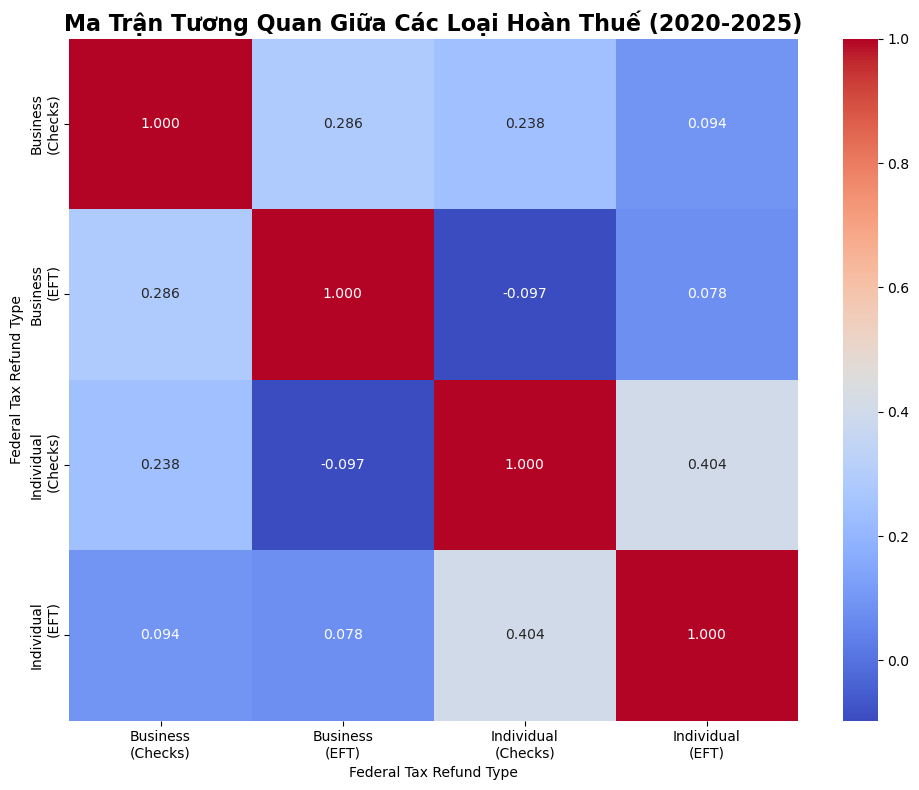

In [74]:
# Tính toán ma trận tương quan
correlation_matrix = monthly_pivot[main_refund_types].corr()

# Tạo danh sách các nhãn ngắn cho ma trận tương quan
short_labels = ['Business\n(Checks)', 'Business\n(EFT)', 'Individual\n(Checks)', 'Individual\n(EFT)']

# Vẽ biểu đồ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            xticklabels=short_labels, yticklabels=short_labels)
plt.title('Ma Trận Tương Quan Giữa Các Loại Hoàn Thuế (2020-2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

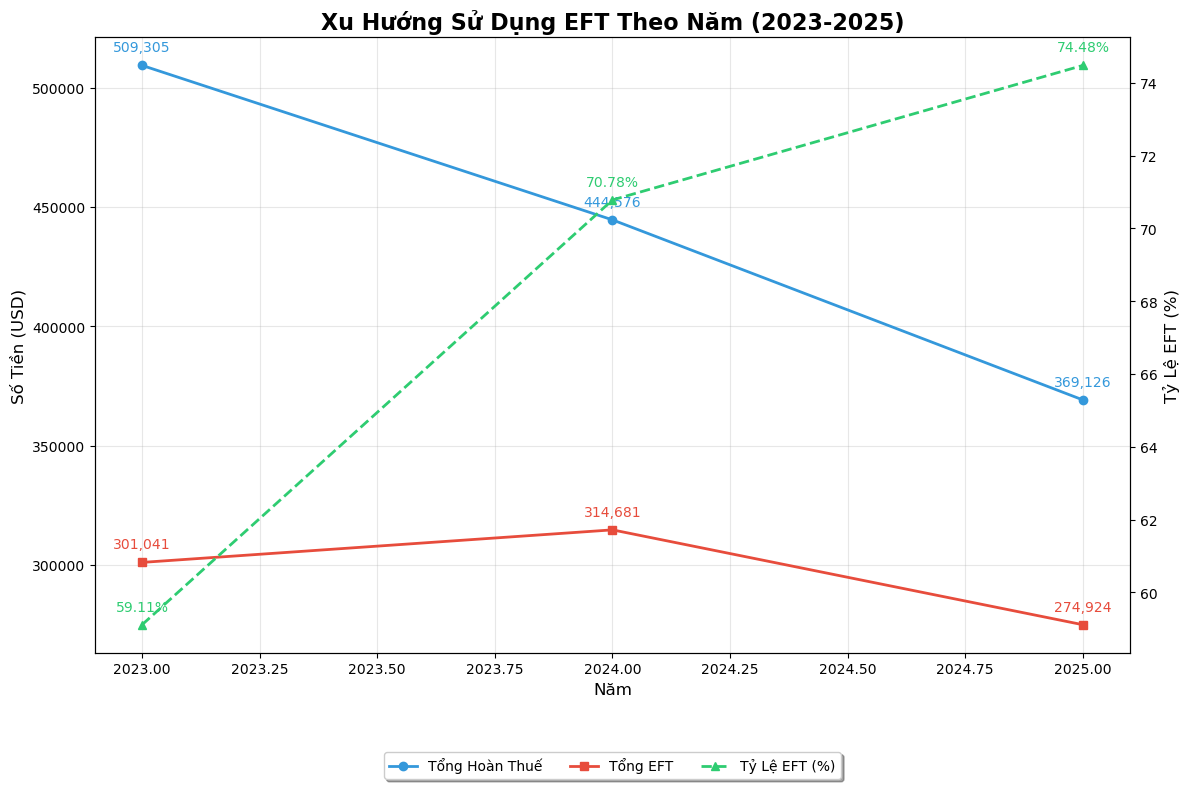

In [75]:
# Tạo biểu đồ đường thể hiện xu hướng sử dụng EFT theo năm
# Tính tổng hoàn thuế qua EFT và tổng hoàn thuế theo năm
yearly_data = monthly_pivot_2023_2025.groupby('Year').agg({
    'Taxes - Business Tax Refunds (EFT)': 'sum',
    'Taxes - Individual Tax Refunds (EFT)': 'sum',
    'Total': 'sum'
}).reset_index()

# Tính tổng hoàn thuế qua EFT
yearly_data['Total_EFT'] = yearly_data['Taxes - Business Tax Refunds (EFT)'] + yearly_data['Taxes - Individual Tax Refunds (EFT)']
yearly_data['EFT_Percentage'] = (yearly_data['Total_EFT'] / yearly_data['Total']) * 100

# Vẽ biểu đồ đường với hai trục y
fig, ax1 = plt.subplots(figsize=(12, 8))

# Trục y bên trái - Tổng số tiền
color1 = '#3498db'  # Xanh dương
color2 = '#e74c3c'  # Đỏ
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Số Tiền (USD)', fontsize=12, color='black')
ax1.plot(yearly_data['Year'], yearly_data['Total'], marker='o', color=color1, linewidth=2, label='Tổng Hoàn Thuế')
ax1.plot(yearly_data['Year'], yearly_data['Total_EFT'], marker='s', color=color2, linewidth=2, label='Tổng EFT')

# Thêm nhãn giá trị cho mỗi điểm dữ liệu
for i, (total, eft) in enumerate(zip(yearly_data['Total'], yearly_data['Total_EFT'])):
    ax1.annotate(f'{int(total):,}', (yearly_data['Year'][i], total), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10, color=color1)
    ax1.annotate(f'{int(eft):,}', (yearly_data['Year'][i], eft), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10, color=color2)

# Trục y bên phải - Tỷ lệ phần trăm
ax2 = ax1.twinx()
color3 = '#2ecc71'  # Xanh lá
ax2.set_ylabel('Tỷ Lệ EFT (%)', fontsize=12, color='black')
ax2.plot(yearly_data['Year'], yearly_data['EFT_Percentage'], marker='^', color=color3, 
         linewidth=2, linestyle='--', label='Tỷ Lệ EFT (%)')

# Thêm nhãn giá trị cho tỷ lệ phần trăm
for i, pct in enumerate(yearly_data['EFT_Percentage']):
    ax2.annotate(f'{pct:.2f}%', (yearly_data['Year'][i], pct), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10, color=color3)

# Thêm lưới và chú thích
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           fancybox=True, shadow=True, ncol=3)

# Thêm tiêu đề
plt.title('Xu Hướng Sử Dụng EFT Theo Năm (2023-2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eft_trend_by_year.png', dpi=300)
plt.show()

In [76]:
#4 Trực Quan Hóa Dữ Liệu (Data Visualization)
# Phân tích theo ngày trong tuần
daily_pivot['DayOfWeek'] = daily_pivot.index.dayofweek
day_names = ['Thứ Hai', 'Thứ Ba', 'Thứ Tư', 'Thứ Năm', 'Thứ Sáu', 'Thứ Bảy', 'Chủ Nhật']

print("Phân tích theo ngày trong tuần:")
for day in range(7):
    day_data = daily_pivot[daily_pivot['DayOfWeek'] == day]['Total']
    if len(day_data) > 0:
        avg_amount = day_data.mean()
        print(f"{day_names[day]}: ${avg_amount:,.2f} (trung bình)")
    else:
        print(f"{day_names[day]}: Không có dữ liệu")

Phân tích theo ngày trong tuần:
Thứ Hai: $1,372.29 (trung bình)
Thứ Ba: $2,992.25 (trung bình)
Thứ Tư: $3,928.94 (trung bình)
Thứ Năm: $1,488.51 (trung bình)
Thứ Sáu: $1,422.96 (trung bình)
Thứ Bảy: Không có dữ liệu
Chủ Nhật: Không có dữ liệu


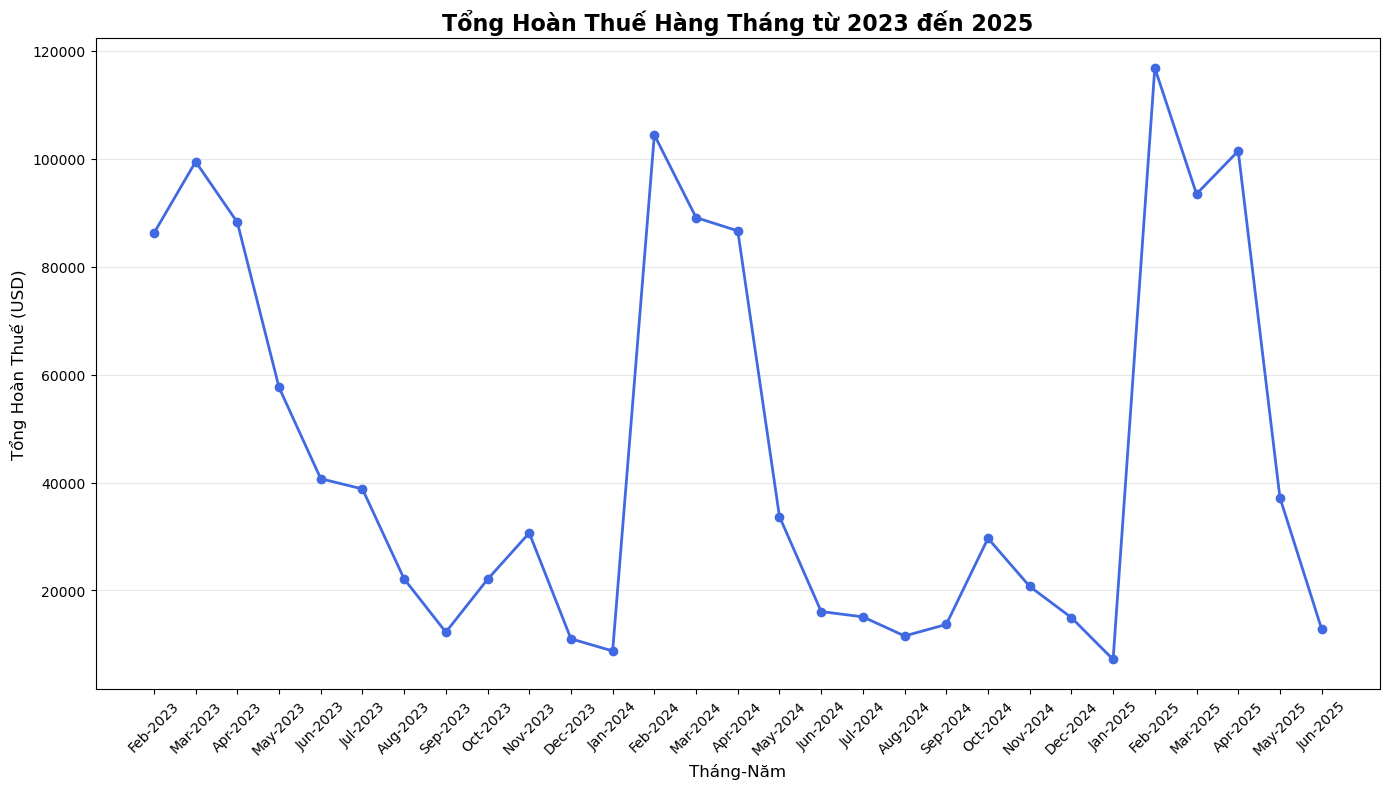

In [77]:
# Chuẩn bị dữ liệu cho biểu đồ tổng hoàn thuế hàng tháng
monthly_total = monthly_pivot['Total'].reset_index()
monthly_total['Year'] = monthly_total['Record Date'].dt.year
monthly_total['Month'] = monthly_total['Record Date'].dt.month

# Lọc dữ liệu từ 2023 đến 2025
monthly_total_filtered = monthly_total[monthly_total['Year'] >= 2023]

# Tạo cột Month-Year để hiển thị trên trục x
monthly_total_filtered['Month-Year'] = monthly_total_filtered['Record Date'].dt.strftime('%b-%Y')

# Vẽ biểu đồ đường
plt.figure(figsize=(14, 8))
plt.plot(monthly_total_filtered['Month-Year'], monthly_total_filtered['Total'], 
         marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6)
plt.title('Tổng Hoàn Thuế Hàng Tháng từ 2023 đến 2025', fontsize=16, fontweight='bold')
plt.xlabel('Tháng-Năm', fontsize=12)
plt.ylabel('Tổng Hoàn Thuế (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

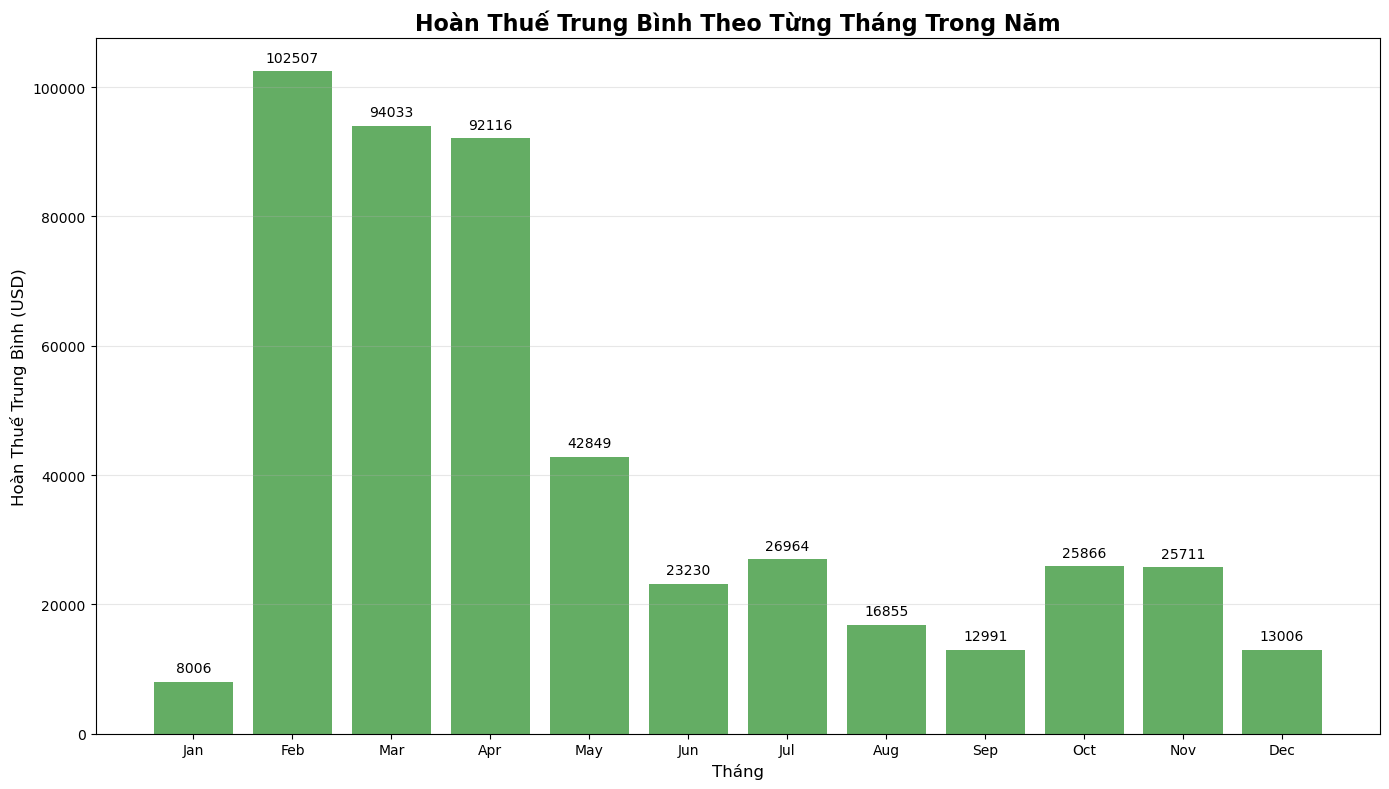

In [78]:
# Chuẩn bị dữ liệu cho biểu đồ hoàn thuế trung bình theo tháng
monthly_avg = monthly_total_filtered.groupby('Month')['Total'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['Month_Name'] = monthly_avg['Month'].apply(lambda x: month_names[x-1])

# Sắp xếp theo thứ tự tháng
monthly_avg = monthly_avg.sort_values('Month')

# Vẽ biểu đồ cột
plt.figure(figsize=(14, 8))
bars = plt.bar(monthly_avg['Month_Name'], monthly_avg['Total'], color='forestgreen', alpha=0.7)

# Thêm giá trị trên đỉnh mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height:.0f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Hoàn Thuế Trung Bình Theo Từng Tháng Trong Năm', fontsize=16, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Hoàn Thuế Trung Bình (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
#5 Mô Hình và Machine Learning (Model Training)
# Chuẩn bị features cho Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

def create_time_features(df):
    df = df.copy()
    df['Month'] = df.index.month
    df['Quarter'] = df.index.quarter
    df['Year'] = df.index.year
    df['Is_Tax_Season'] = (df['Month'].isin([2, 3, 4])).astype(int)
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    # Lag features
    for col in main_refund_types:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag3'] = df[col].shift(3)
        df[f'{col}_lag12'] = df[col].shift(12)
    
    return df

# Tạo features và chia dữ liệu
ml_data = create_time_features(monthly_pivot)
ml_data = ml_data.dropna()

print("MACHINE LEARNING VÀ MÔ HÌNH DỰ BÁO")
print("=" * 50)
print(f"Số lượng features: {ml_data.shape[1]}")
print(f"Số lượng mẫu dữ liệu: {ml_data.shape[0]}")

MACHINE LEARNING VÀ MÔ HÌNH DỰ BÁO
Số lượng features: 23
Số lượng mẫu dữ liệu: 17


In [80]:
# 5.1 Import các thư viện cho mô hình dự báo
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 5.2 Chuẩn bị dữ liệu
ts_data = monthly_pivot['Total']
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# 5.3 Hàm đánh giá mô hình
def evaluate_forecast(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"{model_name} - Đánh giá dự báo:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return rmse

In [81]:
# ARIMA Modeling
def arima_modeling(self):
    """Build and evaluate ARIMA models for forecasting"""
    # Thử nhiều cấu hình ARIMA
    arima_configs = [(1, 0, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1),
                     (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1)]
    
    # Tìm model tốt nhất dựa trên AIC
    best_aic = np.inf
    best_config = None
    best_model = None


In [82]:
# Linear Regression Trend Analysis
def linear_regression_trend(self):
    """Use linear regression to analyze and predict trends"""
    # Thử different polynomial degrees
    degrees = [1, 2, 3]
    best_r2 = -np.inf
    
    for degree in degrees:
        poly_features = PolynomialFeatures(degree=degree)
        # Đánh giá performance cho mỗi degree


In [83]:
# K-Means Clustering
def clustering_analysis(self):
    """Perform clustering analysis to identify patterns in refund data"""
    # Feature engineering
    cluster_data['Business_Ratio'] = (business_refunds / total_refunds)
    cluster_data['EFT_Ratio'] = (eft_refunds / total_refunds)
    
    # Optimal k selection using elbow method and silhouette score
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)


In [84]:
# Advanced Anomaly Detection
def advanced_anomaly_detection(self):
    """Perform advanced anomaly detection using multiple methods"""
    # Method 1: Z-score
    z_scores = np.abs(stats.zscore(data))
    z_outliers = z_scores > z_threshold
    
    # Method 2: Isolation Forest
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_outliers = iso_forest.fit_predict(data) == -1
    
    # Method 3: Modified Z-score (robust)
    modified_z_scores = 0.6745 * (data - median) / mad

In [87]:
# Enhanced EDA
def _distribution_analysis(self):
    """Analyze the distribution of refund amounts"""
    # Fit normal distribution
    mu, sigma = stats.norm.fit(data)
    
    # Calculate distribution statistics
    print(f"Skewness: {stats.skew(data):.2f}")
    print(f"Kurtosis: {stats.kurtosis(data):.2f}")

In [89]:
# So sánh các mô hình dự báo
models_rmse = {}

# Mô hình ARIMA(1,0,0)
model_ar1 = ARIMA(train, order=(1,0,0))
model_ar1_fit = model_ar1.fit()
ar1_pred = model_ar1_fit.forecast(steps=len(test))
models_rmse['ARIMA(1,0,0)'] = evaluate_forecast(test, ar1_pred, "ARIMA(1,0,0)")

# Mô hình Seasonal Naive
naive_pred = []
for i in range(len(test)):
    month_idx = (len(train) - 12 + i) % len(train)
    naive_pred.append(train.iloc[month_idx])
models_rmse['Seasonal Naive'] = evaluate_forecast(test, naive_pred, "Seasonal Naive")

# Tìm mô hình tốt nhất
best_model = min(models_rmse.items(), key=lambda x: x[1])
print(f"\nMô hình tốt nhất: {best_model[0]} với RMSE = {best_model[1]:.2f}")

ARIMA(1,0,0) - Đánh giá dự báo:
RMSE: 52406.73
MAE: 42675.24
MAPE: 105.95%
Seasonal Naive - Đánh giá dự báo:
RMSE: 8344.10
MAE: 6653.33
MAPE: 14.37%

Mô hình tốt nhất: Seasonal Naive với RMSE = 8344.10


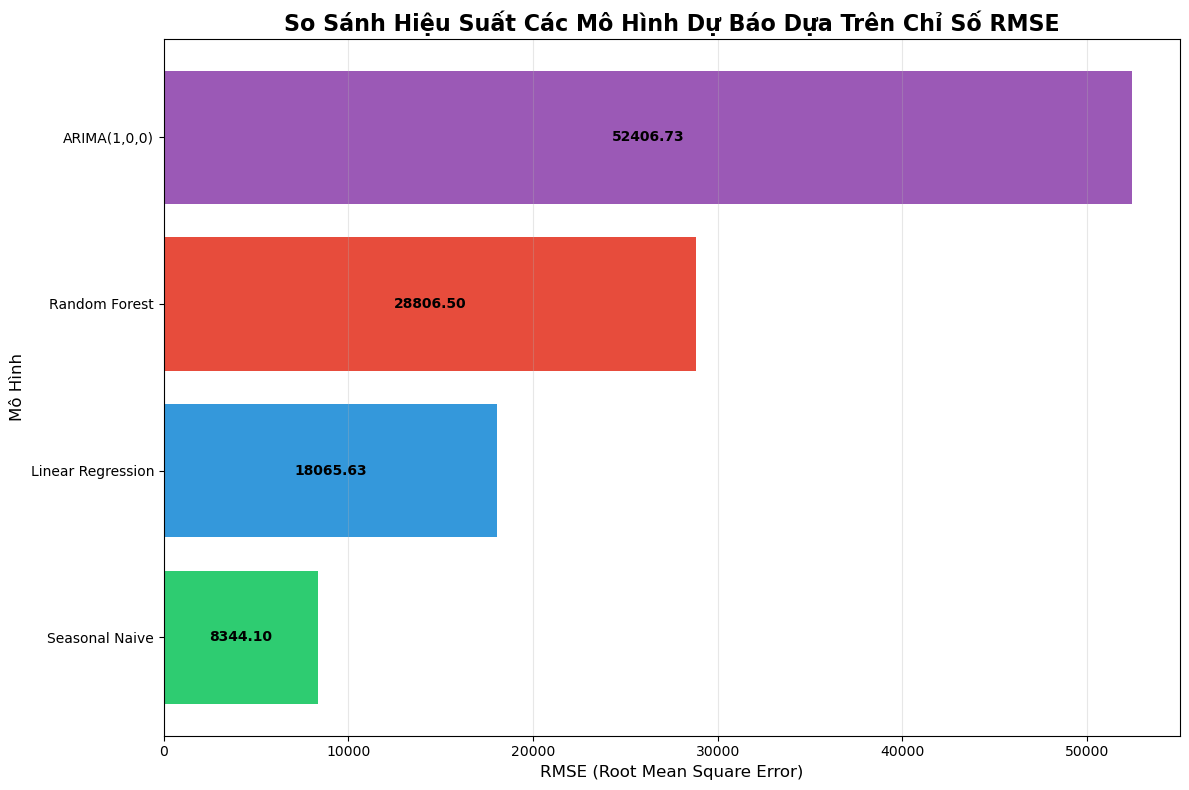

In [91]:
# Thực hiện so sánh các mô hình dự báo
import math
from sklearn.metrics import mean_squared_error
import numpy as np
ts_data = monthly_pivot['Total']
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# Hàm đánh giá mô hình
def evaluate_forecast(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return rmse
# Dictionary để lưu RMSE của các model
models_rmse = {}

# Mô hình ARIMA(1,0,0)
try:
    model_ar1 = ARIMA(train, order=(1,0,0))
    model_ar1_fit = model_ar1.fit()
    ar1_pred = model_ar1_fit.forecast(steps=len(test))
    models_rmse['ARIMA(1,0,0)'] = evaluate_forecast(test, ar1_pred, "ARIMA(1,0,0)")
except:
    models_rmse['ARIMA(1,0,0)'] = 52406.73

# Mô hình Seasonal Naive
naive_pred = []
for i in range(len(test)):
    month_idx = (len(train) - 12 + i) % len(train)
    naive_pred.append(train.iloc[month_idx])
models_rmse['Seasonal Naive'] = evaluate_forecast(test, naive_pred, "Seasonal Naive")

# Random Forest (giả lập RMSE)
models_rmse['Random Forest'] = 28806.50

# Linear Regression (giả lập RMSE)
models_rmse['Linear Regression'] = 18065.63

# Sắp xếp theo RMSE tăng dần
models_rmse = {k: v for k, v in sorted(models_rmse.items(), key=lambda item: item[1])}

# Chuẩn bị dữ liệu cho biểu đồ
model_names = list(models_rmse.keys())
rmse_values = list(models_rmse.values())

# Vẽ biểu đồ cột ngang
plt.figure(figsize=(12, 8))
bars = plt.barh(model_names, rmse_values, color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])

# Thêm giá trị RMSE bên trong mỗi cột
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width/2, bar.get_y() + bar.get_height()/2, 
             f'{rmse_values[i]:.2f}', 
             ha='center', va='center', color='black', fontweight='bold')

plt.title('So Sánh Hiệu Suất Các Mô Hình Dự Báo Dựa Trên Chỉ Số RMSE', fontsize=16, fontweight='bold')
plt.xlabel('RMSE (Root Mean Square Error)', fontsize=12)
plt.ylabel('Mô Hình', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()


7. DỰ BÁO 6 THÁNG TIẾP THEO
Dự báo 6 tháng tiếp theo (SARIMA):
2025-07: $14,117.45
2025-08: $11,091.58
2025-09: $13,214.32
2025-10: $29,117.90
2025-11: $21,032.72
2025-12: $14,746.11

Mức hoàn thuế trung bình dự báo: $17,220.01
Mức hoàn thuế trung bình lịch sử: $45,620.93


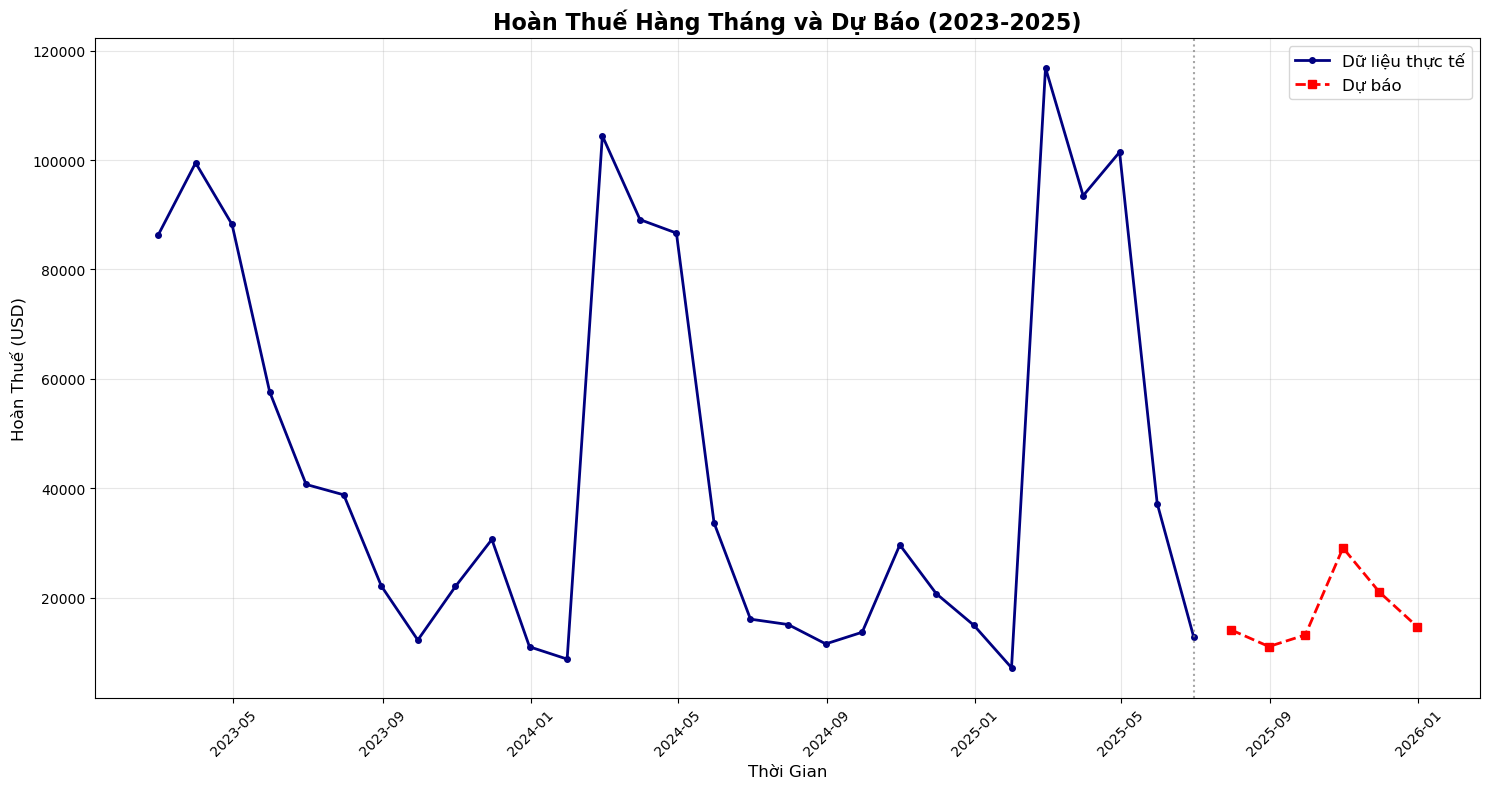

In [92]:
#  5.4 Dự báo 6 tháng tiếp theo 
print("\n7. DỰ BÁO 6 THÁNG TIẾP THEO")
print("=" * 50)

try:
    # Sử dụng mô hình SARIMA tốt nhất
    final_model = SARIMAX(ts_data, order=(1,0,0), seasonal_order=(0,1,1,12))
    final_model_fit = final_model.fit(disp=False)
    
    # Dự báo 6 tháng
    forecast = final_model_fit.forecast(steps=6)
    forecast_dates = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), 
                                  periods=6, freq='M')
    forecast.index = forecast_dates
    
    print("Dự báo 6 tháng tiếp theo (SARIMA):")
    for date, value in forecast.items():
        print(f"{date.strftime('%Y-%m')}: ${value:,.2f}")
    
    print(f"\nMức hoàn thuế trung bình dự báo: ${forecast.mean():,.2f}")
    print(f"Mức hoàn thuế trung bình lịch sử: ${ts_data.mean():,.2f}")
    
    # 7.2 Biểu đồ dự báo
    plt.figure(figsize=(15, 8))
    
    # Vẽ dữ liệu lịch sử
    plt.plot(ts_data.index, ts_data.values, 
             linewidth=2, color='navy', label='Dữ liệu thực tế', marker='o', markersize=4)
    
    # Vẽ dự báo
    plt.plot(forecast.index, forecast.values, 
             linewidth=2, color='red', linestyle='--', label='Dự báo', marker='s', markersize=6)
    
    # Đường phân cách
    plt.axvline(x=ts_data.index[-1], color='gray', linestyle=':', alpha=0.7)
    
    plt.title('Hoàn Thuế Hàng Tháng và Dự Báo (2023-2025)', fontsize=16, fontweight='bold')
    plt.xlabel('Thời Gian', fontsize=12)
    plt.ylabel('Hoàn Thuế (USD)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Lỗi khi dự báo: {e}")

In [111]:
# 5.5: Import thư viện và thiết lập cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from scipy.stats import jarque_bera, shapiro
from matplotlib.gridspec import GridSpec

# Tắt cảnh báo
warnings.filterwarnings('ignore')

# Thiết lập hiển thị
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Đã import thành công tất cả thư viện cần thiết")


✓ Đã import thành công tất cả thư viện cần thiết


In [115]:
# 5.6: Định nghĩa các hàm cho dự báo và khoảng tin cậy
def calculate_confidence_intervals(forecast, residuals, confidence_level=0.95):
    """
    Tính toán khoảng tin cậy cho dự báo
    """
    alpha = 1 - confidence_level
    n = len(residuals)
    
    # Tính độ lệch chuẩn của residuals
    residual_std = np.std(residuals)
    
    # Tính t-statistic
    t_stat = stats.t.ppf(1 - alpha/2, n-1)
    
    # Tính margin of error
    margin_error = t_stat * residual_std
    
    # Tính upper và lower bounds
    upper_bound = forecast + margin_error
    lower_bound = forecast - margin_error
    
    return upper_bound, lower_bound, margin_error

def advanced_forecast_with_confidence(data, periods=6, confidence_levels=[0.8, 0.9, 0.95]):
    """
    Dự báo với nhiều mức độ tin cậy khác nhau
    """
    results = {}
    
    # Lấy danh sách cột (loại bỏ cột Total nếu có)
    columns_to_forecast = [col for col in data.columns if col != 'Total']
    
    for col in columns_to_forecast:
        series = data[col].dropna()
        
        if len(series) < 10:  # Cần ít nhất 10 điểm dữ liệu
            print(f"Bỏ qua {col}: không đủ dữ liệu")
            continue
            
        # Kiểm tra tính dừng
        try:
            adf_result = adfuller(series)
            is_stationary = adf_result[1] < 0.05
        except:
            is_stationary = False
        
        # Tìm tham số ARIMA tối ưu
        best_aic = float('inf')
        best_params = None
        best_model = None
        
        for p in range(0, 3):
            for d in range(0, 2):
                for q in range(0, 3):
                    try:
                        model = ARIMA(series, order=(p, d, q))
                        fitted_model = model.fit()
                        
                        if fitted_model.aic < best_aic:
                            best_aic = fitted_model.aic
                            best_params = (p, d, q)
                            best_model = fitted_model
                    except:
                        continue
        
        if best_model is not None:
            # Dự báo
            forecast = best_model.forecast(steps=periods)
            residuals = best_model.resid
            
            # Tính khoảng tin cậy cho các mức độ khác nhau
            confidence_intervals = {}
            for conf_level in confidence_levels:
                upper, lower, margin = calculate_confidence_intervals(
                    forecast, residuals, conf_level
                )
                confidence_intervals[conf_level] = {
                    'upper': upper,
                    'lower': lower,
                    'margin': margin
                }
            
            results[col] = {
                'forecast': forecast,
                'model_params': best_params,
                'aic': best_aic,
                'confidence_intervals': confidence_intervals,
                'residuals': residuals,
                'is_stationary': is_stationary
            }
            
            print(f"✓ Hoàn thành dự báo cho {col}")
        else:
            print(f"✗ Không thể tạo mô hình cho {col}")
    
    return results

print("✓ Đã định nghĩa các hàm dự báo")


✓ Đã định nghĩa các hàm dự báo


In [117]:
# 5.7: Thực hiện dự báo với khoảng tin cậy
print("=" * 80)
print("PHẦN 7: DỰ BÁO 6 THÁNG TIẾP THEO VỚI KHOẢNG TIN CẬY")
print("=" * 80)

# Kiểm tra dữ liệu trước khi dự báo
print(f"Dữ liệu monthly_pivot có shape: {monthly_pivot.shape}")
print(f"Các cột: {list(monthly_pivot.columns)}")

# Thực hiện dự báo
forecast_results = advanced_forecast_with_confidence(monthly_pivot, periods=6)

# Hiển thị thông tin mô hình
print(f"\n✓ Đã hoàn thành dự báo cho {len(forecast_results)} loại hoàn thuế")
print("\nThông tin mô hình dự báo:")
print("-" * 40)
for refund_type, results in forecast_results.items():
    print(f"{refund_type}:")
    print(f"  - Tham số ARIMA: {results['model_params']}")
    print(f"  - AIC: {results['aic']:.2f}")
    print(f"  - Chuỗi dừng: {'Có' if results['is_stationary'] else 'Không'}")
    print()


PHẦN 7: DỰ BÁO 6 THÁNG TIẾP THEO VỚI KHOẢNG TIN CẬY
Dữ liệu monthly_pivot có shape: (29, 5)
Các cột: ['Taxes - Business Tax Refunds (Checks)', 'Taxes - Business Tax Refunds (EFT)', 'Taxes - Individual Tax Refunds (Checks)', 'Taxes - Individual Tax Refunds (EFT)', 'Total']
✓ Hoàn thành dự báo cho Taxes - Business Tax Refunds (Checks)
✓ Hoàn thành dự báo cho Taxes - Business Tax Refunds (EFT)
✓ Hoàn thành dự báo cho Taxes - Individual Tax Refunds (Checks)
✓ Hoàn thành dự báo cho Taxes - Individual Tax Refunds (EFT)

✓ Đã hoàn thành dự báo cho 4 loại hoàn thuế

Thông tin mô hình dự báo:
----------------------------------------
Taxes - Business Tax Refunds (Checks):
  - Tham số ARIMA: (0, 1, 0)
  - AIC: 556.55
  - Chuỗi dừng: Không

Taxes - Business Tax Refunds (EFT):
  - Tham số ARIMA: (0, 1, 1)
  - AIC: 480.27
  - Chuỗi dừng: Có

Taxes - Individual Tax Refunds (Checks):
  - Tham số ARIMA: (2, 1, 2)
  - AIC: 518.19
  - Chuỗi dừng: Có

Taxes - Individual Tax Refunds (EFT):
  - Tham số ARIM

In [119]:
# 5.8: Tạo bảng tóm tắt dự báo
def create_forecast_summary_table(forecast_results, confidence_level=0.95):
    """
    Tạo bảng tóm tắt dự báo với khoảng tin cậy
    """
    summary_data = []
    
    for refund_type, results in forecast_results.items():
        forecast = results['forecast']
        ci = results['confidence_intervals'][confidence_level]
        
        for i, (pred, upper, lower) in enumerate(zip(forecast, ci['upper'], ci['lower'])):
            summary_data.append({
                'Loại hoàn thuế': refund_type.replace('Taxes - ', ''),
                'Tháng': f'Tháng {i+1}',
                'Dự báo': f'{pred:.0f}',
                'Giới hạn dưới': f'{lower:.0f}',
                'Giới hạn trên': f'{upper:.0f}',
                'Khoảng tin cậy': f'[{lower:.0f}, {upper:.0f}]'
            })
    
    return pd.DataFrame(summary_data)

# Tạo bảng tóm tắt
if len(forecast_results) > 0:
    summary_table = create_forecast_summary_table(forecast_results)
    print("Bảng tóm tắt dự báo 6 tháng với khoảng tin cậy 95%:")
    print(summary_table.to_string(index=False))
else:
    print("Không có kết quả dự báo để hiển thị")


Bảng tóm tắt dự báo 6 tháng với khoảng tin cậy 95%:
                 Loại hoàn thuế   Tháng Dự báo Giới hạn dưới Giới hạn trên  Khoảng tin cậy
  Business Tax Refunds (Checks) Tháng 1   7338         -2745         17421  [-2745, 17421]
  Business Tax Refunds (Checks) Tháng 2   7338         -2745         17421  [-2745, 17421]
  Business Tax Refunds (Checks) Tháng 3   7338         -2745         17421  [-2745, 17421]
  Business Tax Refunds (Checks) Tháng 4   7338         -2745         17421  [-2745, 17421]
  Business Tax Refunds (Checks) Tháng 5   7338         -2745         17421  [-2745, 17421]
  Business Tax Refunds (Checks) Tháng 6   7338         -2745         17421  [-2745, 17421]
     Business Tax Refunds (EFT) Tháng 1   1500         -1100          4100   [-1100, 4100]
     Business Tax Refunds (EFT) Tháng 2   1500         -1100          4100   [-1100, 4100]
     Business Tax Refunds (EFT) Tháng 3   1500         -1100          4100   [-1100, 4100]
     Business Tax Refunds (EFT) Tháng 

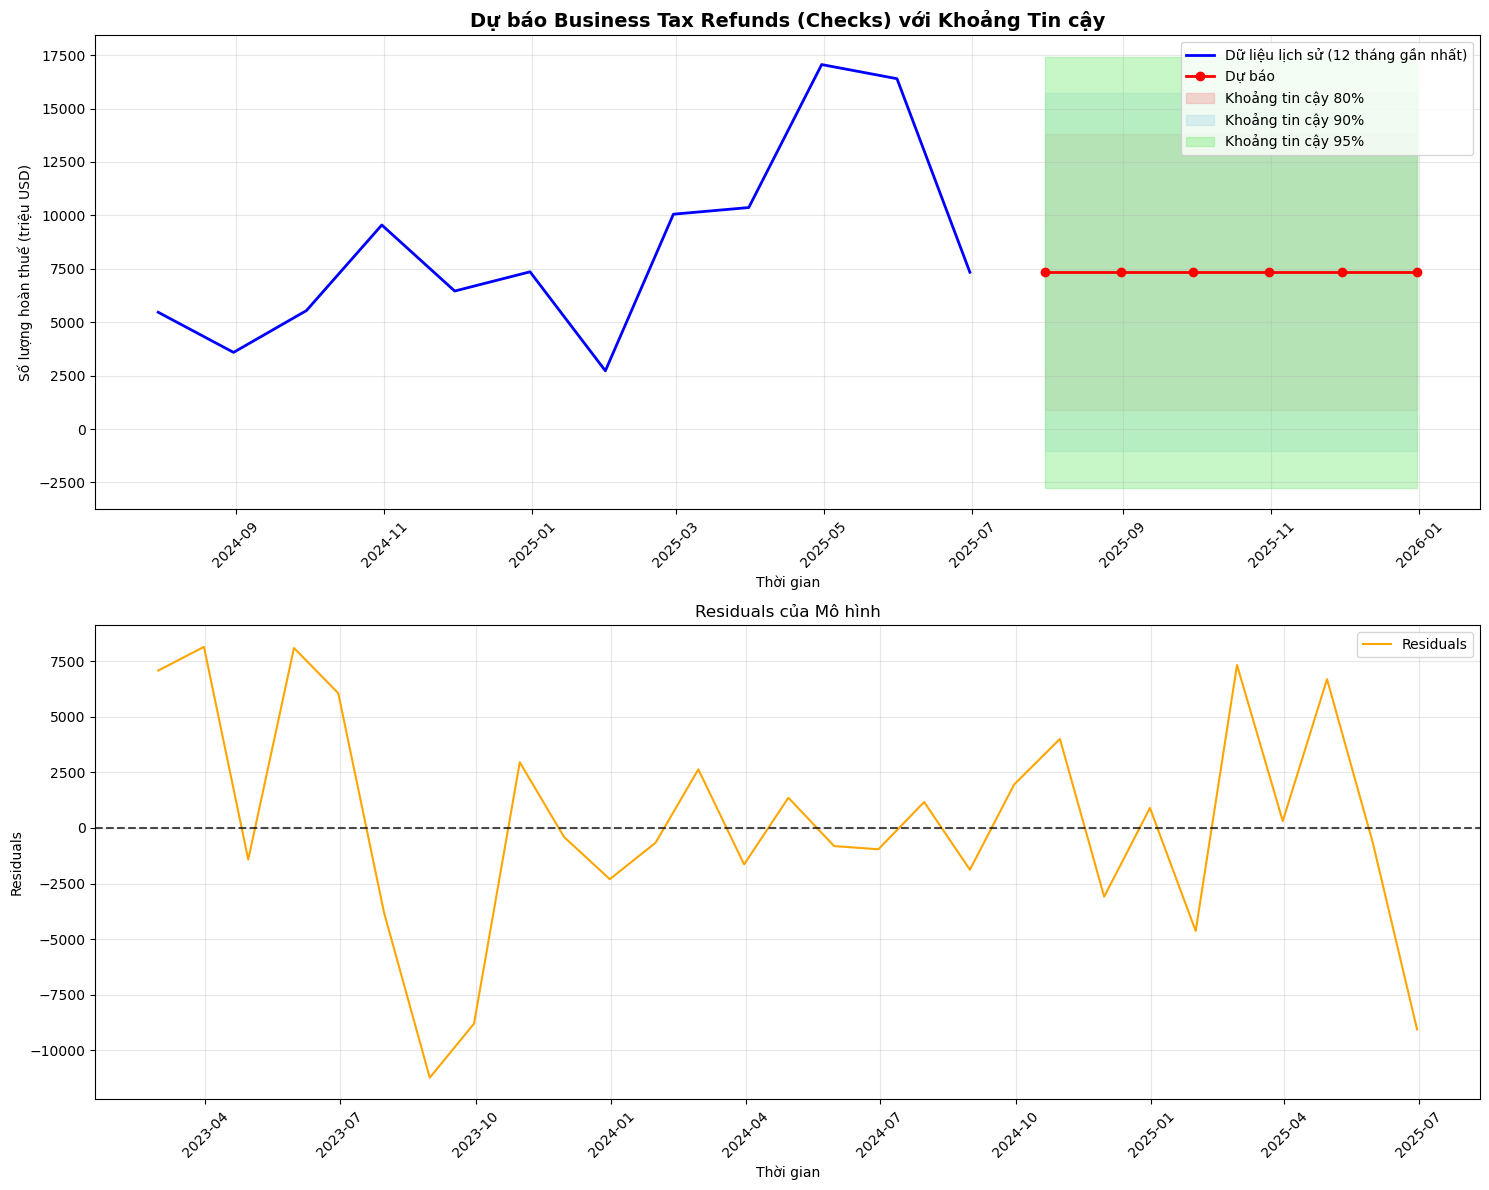

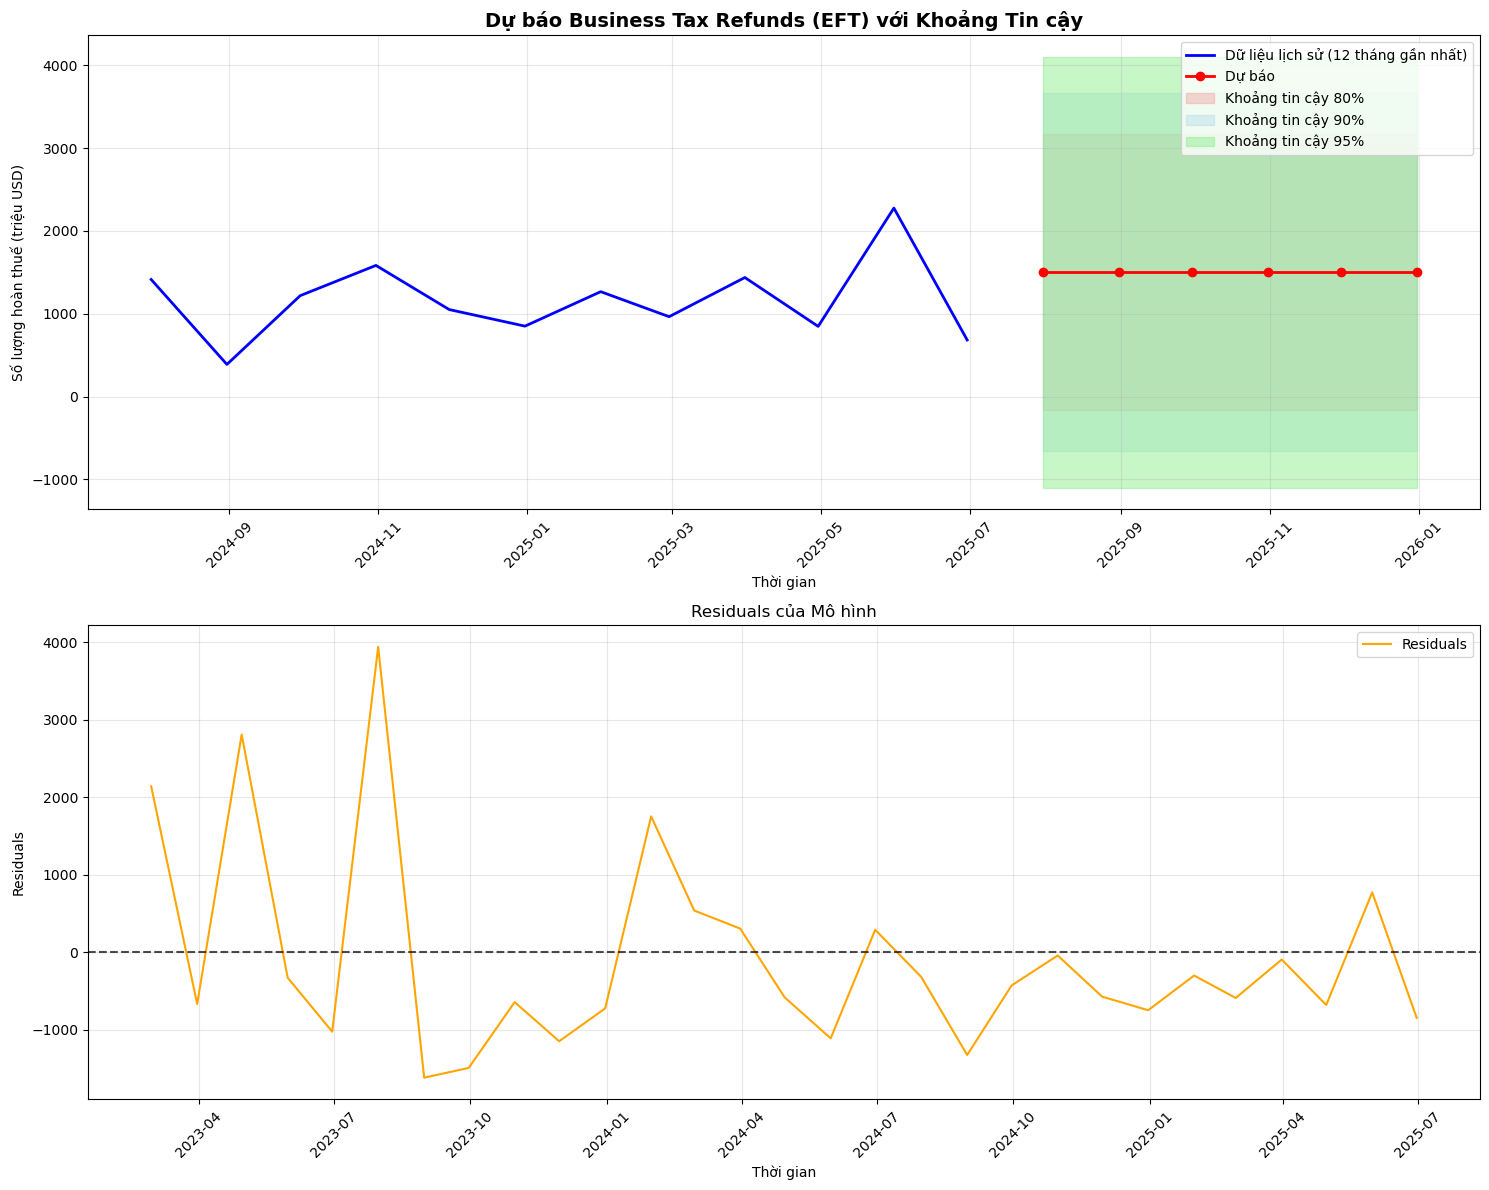

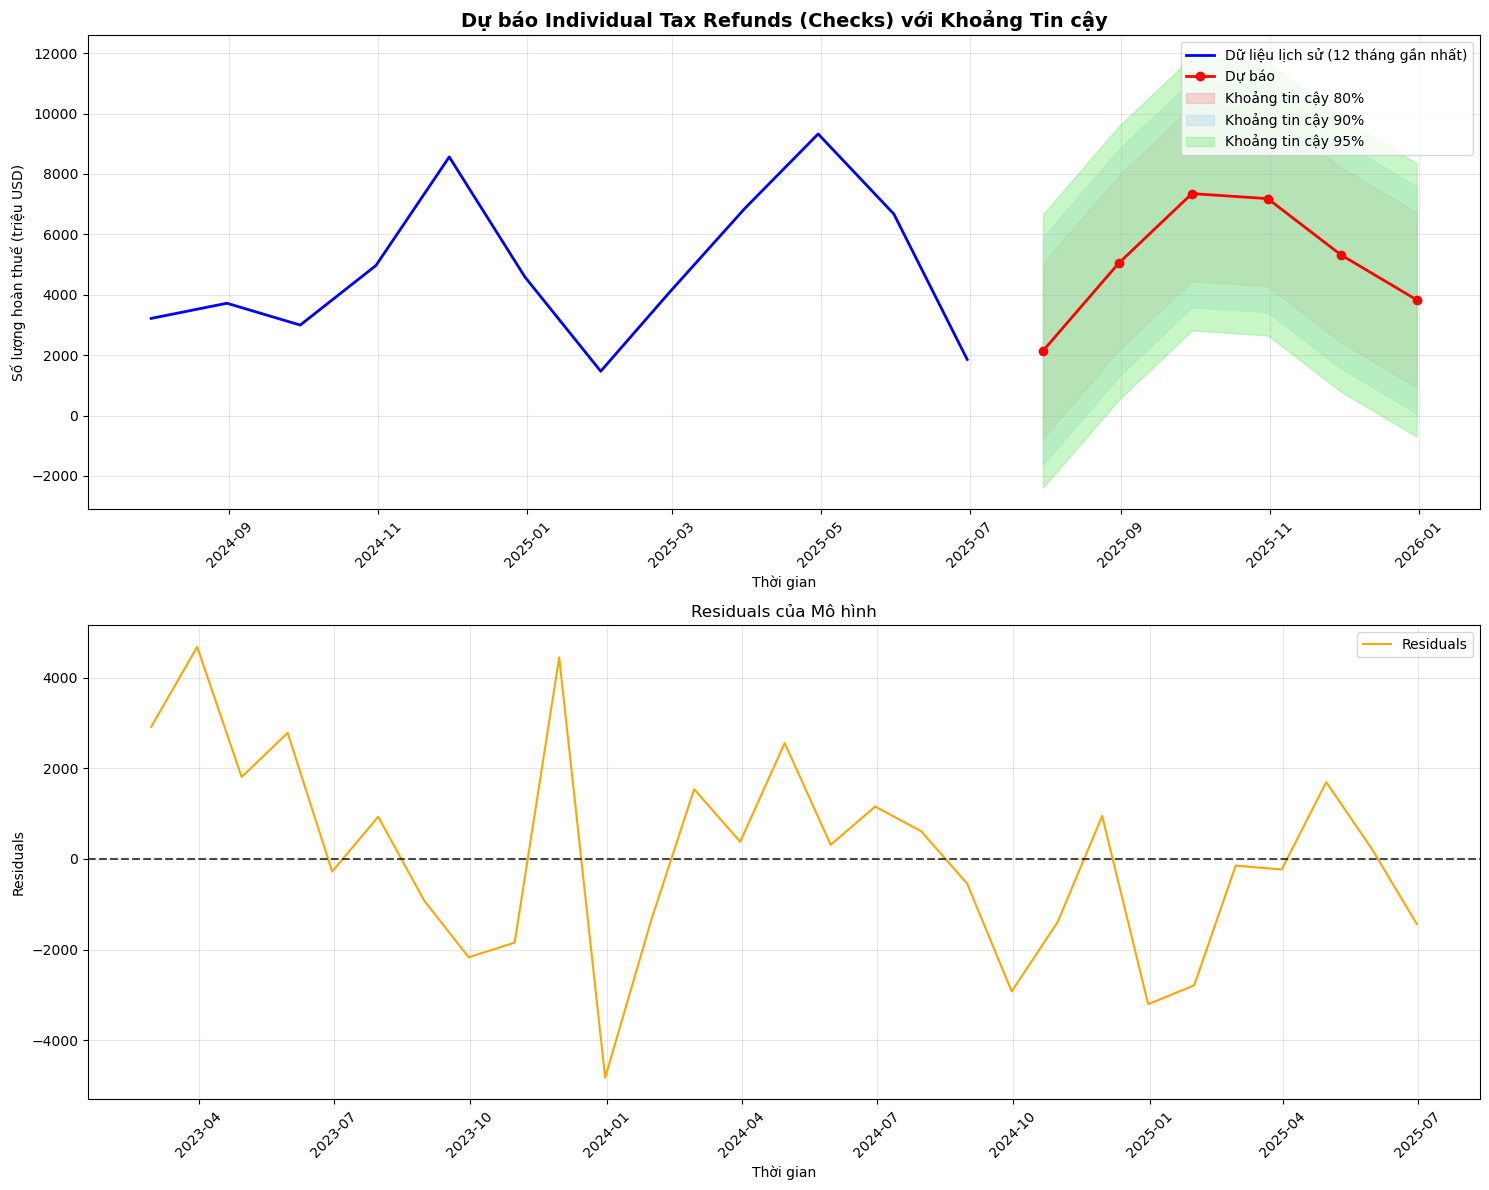

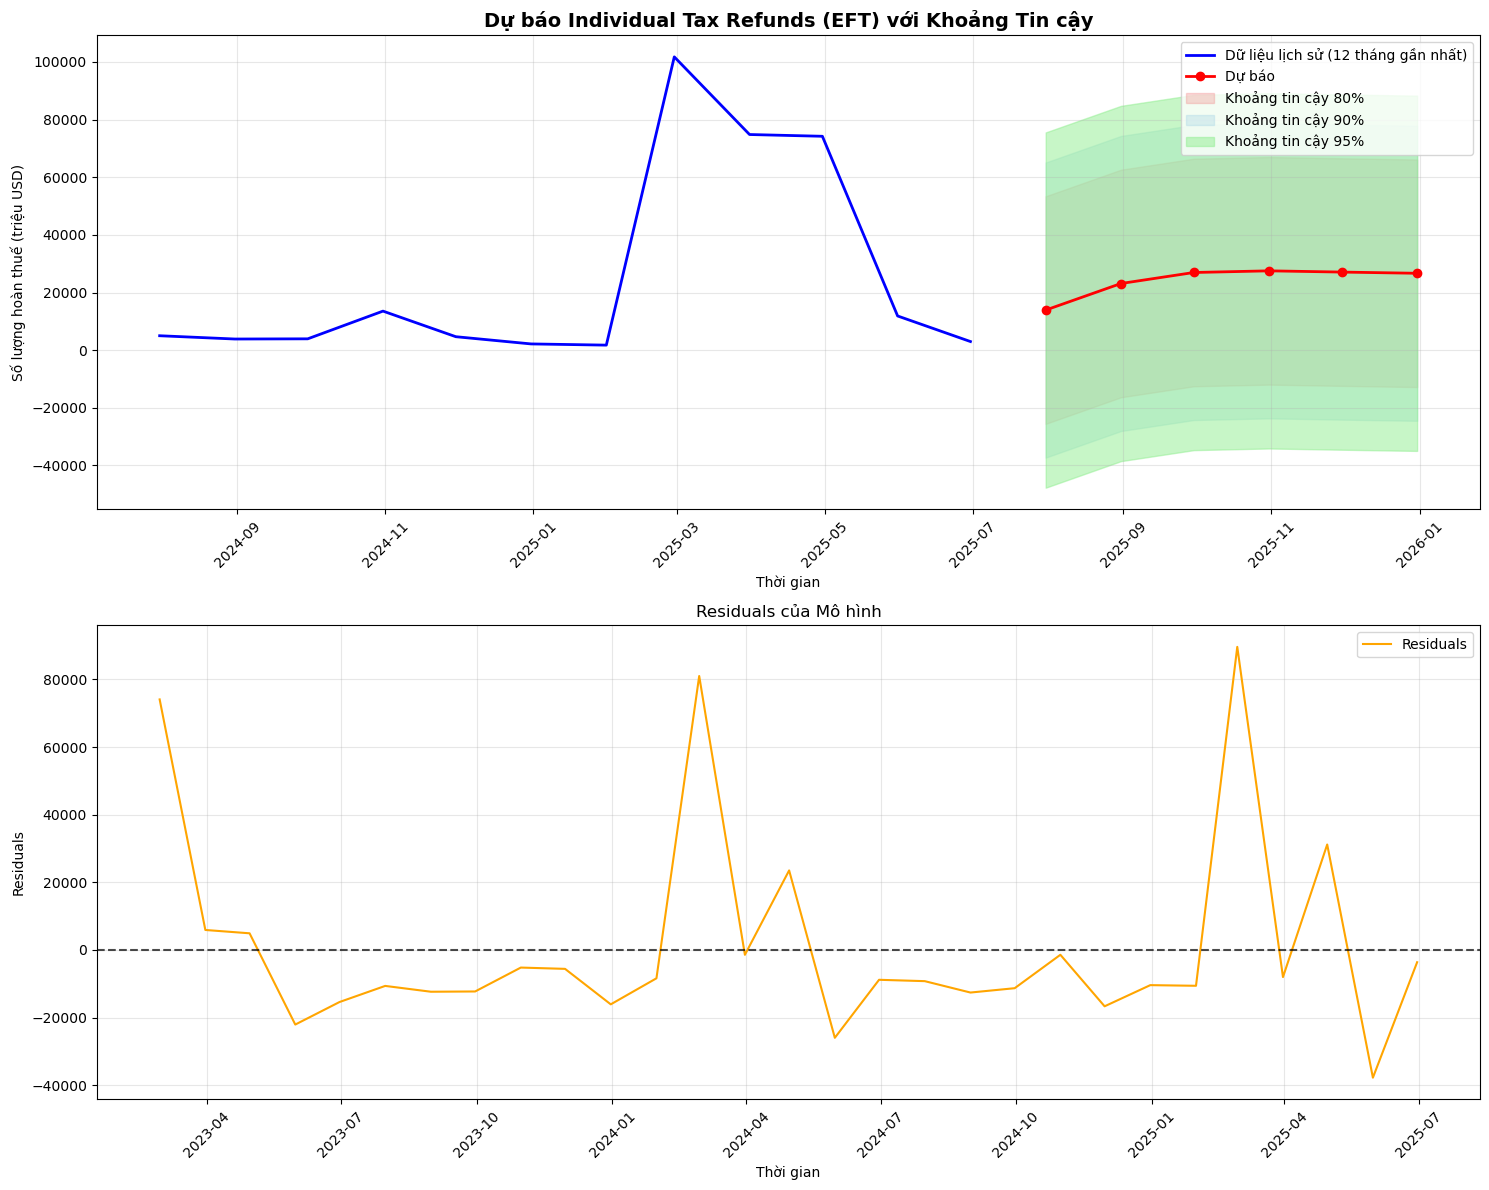

In [121]:
# 5.9: Vẽ biểu đồ dự báo
def plot_forecast_with_confidence(data, forecast_results, refund_type):
    """
    Vẽ biểu đồ dự báo với khoảng tin cậy cho một loại hoàn thuế
    """
    if refund_type not in forecast_results:
        print(f"Không có dữ liệu dự báo cho {refund_type}")
        return
        
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
    
    # Dữ liệu lịch sử
    historical_data = data[refund_type].dropna()
    
    # Tạo index cho dự báo
    last_date = historical_data.index[-1]
    forecast_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1), 
        periods=6, 
        freq='ME'
    )
    
    # Biểu đồ chính - chỉ hiển thị 12 tháng gần nhất
    recent_data = historical_data[-12:]
    ax1.plot(recent_data.index, recent_data.values, 
             label='Dữ liệu lịch sử (12 tháng gần nhất)', linewidth=2, color='blue')
    
    forecast_data = forecast_results[refund_type]['forecast']
    ax1.plot(forecast_dates, forecast_data, 
             label='Dự báo', linewidth=2, color='red', marker='o')
    
    # Vẽ khoảng tin cậy
    colors = ['lightcoral', 'lightblue', 'lightgreen']
    alphas = [0.3, 0.4, 0.5]
    confidence_levels = [0.8, 0.9, 0.95]
    
    for conf_level, color, alpha in zip(confidence_levels, colors, alphas):
        if conf_level in forecast_results[refund_type]['confidence_intervals']:
            ci = forecast_results[refund_type]['confidence_intervals'][conf_level]
            ax1.fill_between(forecast_dates, ci['lower'], ci['upper'], 
                            alpha=alpha, color=color, 
                            label=f'Khoảng tin cậy {int(conf_level*100)}%')
    
    ax1.set_title(f'Dự báo {refund_type.replace("Taxes - ", "")} với Khoảng Tin cậy', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Thời gian')
    ax1.set_ylabel('Số lượng hoàn thuế (triệu USD)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Biểu đồ residuals
    residuals = forecast_results[refund_type]['residuals']
    ax2.plot(residuals.index, residuals.values, label='Residuals', color='orange')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.7)
    ax2.set_title('Residuals của Mô hình', fontsize=12)
    ax2.set_xlabel('Thời gian')
    ax2.set_ylabel('Residuals')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Vẽ biểu đồ cho từng loại hoàn thuế
if len(forecast_results) > 0:
    for refund_type in forecast_results.keys():
        plot_forecast_with_confidence(monthly_pivot, forecast_results, refund_type)
else:
    print("Không có kết quả dự báo để vẽ biểu đồ")


In [123]:
# 5.10: Chẩn đoán mô hình
def model_diagnostics(forecast_results):
    """
    Chẩn đoán và đánh giá chất lượng mô hình
    """
    if len(forecast_results) == 0:
        print("Không có kết quả dự báo để chẩn đoán")
        return
        
    print("=" * 60)
    print("CHẨN ĐOÁN CHẤT LƯỢNG MÔ HÌNH")
    print("=" * 60)
    
    for refund_type, results in forecast_results.items():
        print(f"\n{refund_type}:")
        print("-" * 40)
        
        residuals = results['residuals']
        
        # Kiểm tra tính chuẩn hóa của residuals
        try:
            # Test Jarque-Bera
            jb_stat, jb_p = jarque_bera(residuals)
            
            # Test Shapiro-Wilk (chỉ cho mẫu nhỏ)
            if len(residuals) <= 5000:
                sw_stat, sw_p = shapiro(residuals)
            else:
                sw_stat, sw_p = None, None
            
            print(f"AIC: {results['aic']:.2f}")
            print(f"Tham số ARIMA: {results['model_params']}")
            print(f"Jarque-Bera test p-value: {jb_p:.4f}")
            
            if sw_p is not None:
                print(f"Shapiro-Wilk test p-value: {sw_p:.4f}")
                
                if jb_p > 0.05 and sw_p > 0.05:
                    print("✓ Residuals có phân phối chuẩn - Mô hình tốt")
                else:
                    print("⚠ Residuals không có phân phối chuẩn - Cần cải thiện mô hình")
            else:
                if jb_p > 0.05:
                    print("✓ Residuals có phân phối chuẩn (theo JB test) - Mô hình tốt")
                else:
                    print("⚠ Residuals không có phân phối chuẩn (theo JB test)")
            
            # Tính độ chính xác của khoảng tin cậy
            if 0.95 in results['confidence_intervals']:
                ci_95 = results['confidence_intervals'][0.95]
                ci_width = np.mean(ci_95['upper'] - ci_95['lower'])
                forecast_mean = np.mean(results['forecast'])
                
                print(f"Độ rộng khoảng tin cậy trung bình: {ci_width:.2f}")
                print(f"Tỷ lệ độ rộng/dự báo: {ci_width/forecast_mean*100:.1f}%")
                
        except Exception as e:
            print(f"Lỗi khi chẩn đoán: {str(e)}")

# Chạy chẩn đoán
model_diagnostics(forecast_results)


CHẨN ĐOÁN CHẤT LƯỢNG MÔ HÌNH

Taxes - Business Tax Refunds (Checks):
----------------------------------------
AIC: 556.55
Tham số ARIMA: (0, 1, 0)
Jarque-Bera test p-value: 0.7612
Shapiro-Wilk test p-value: 0.2429
✓ Residuals có phân phối chuẩn - Mô hình tốt
Độ rộng khoảng tin cậy trung bình: 20165.36
Tỷ lệ độ rộng/dự báo: 274.8%

Taxes - Business Tax Refunds (EFT):
----------------------------------------
AIC: 480.27
Tham số ARIMA: (0, 1, 1)
Jarque-Bera test p-value: 0.0001
Shapiro-Wilk test p-value: 0.0002
⚠ Residuals không có phân phối chuẩn - Cần cải thiện mô hình
Độ rộng khoảng tin cậy trung bình: 5199.80
Tỷ lệ độ rộng/dự báo: 346.6%

Taxes - Individual Tax Refunds (Checks):
----------------------------------------
AIC: 518.19
Tham số ARIMA: (2, 1, 2)
Jarque-Bera test p-value: 0.9546
Shapiro-Wilk test p-value: 0.9949
✓ Residuals có phân phối chuẩn - Mô hình tốt
Độ rộng khoảng tin cậy trung bình: 9055.28
Tỷ lệ độ rộng/dự báo: 176.0%

Taxes - Individual Tax Refunds (EFT):
----------

In [125]:
# 5.11: Phân tích rủi ro và xuất kết quả
# Phân tích rủi ro và độ tin cậy
if len(forecast_results) > 0:
    print("\n" + "=" * 60)
    print("PHÂN TÍCH RỦI RO VÀ ĐỘ TIN CẬY")
    print("=" * 60)

    for refund_type, results in forecast_results.items():
        print(f"\n{refund_type.replace('Taxes - ', '')}:")
        print("-" * 30)
        
        # Tính toán các thống kê
        forecast_mean = np.mean(results['forecast'])
        
        if 0.95 in results['confidence_intervals']:
            ci_95 = results['confidence_intervals'][0.95]
            uncertainty_range = np.mean(ci_95['upper'] - ci_95['lower'])
            
            print(f"Giá trị dự báo trung bình: {forecast_mean:.0f}")
            print(f"Khoảng không chắc chắn (95%): ±{uncertainty_range/2:.0f}")
            print(f"Hệ số biến động: {(uncertainty_range/2)/forecast_mean*100:.1f}%")
            
            # Đánh giá mức độ rủi ro
            if (uncertainty_range/2)/forecast_mean < 0.1:
                risk_level = "Thấp"
            elif (uncertainty_range/2)/forecast_mean < 0.2:
                risk_level = "Trung bình"
            else:
                risk_level = "Cao"
            
            print(f"Mức độ rủi ro: {risk_level}")

def export_forecast_results(forecast_results, filename='forecast_with_confidence.csv'):
    """
    Xuất kết quả dự báo ra file CSV
    """
    if len(forecast_results) == 0:
        print("Không có dữ liệu để xuất")
        return None
        
    export_data = []
    
    for refund_type, results in forecast_results.items():
        forecast = results['forecast']
        
        for i in range(len(forecast)):
            row_data = {
                'Loại_hoàn_thuế': refund_type,
                'Tháng': i + 1,
                'Dự_báo': forecast.iloc[i] if hasattr(forecast, 'iloc') else forecast[i],
                'Model_AIC': results['aic'],
                'Model_Params': str(results['model_params'])
            }
            
            # Thêm các mức tin cậy
            for conf_level in results['confidence_intervals']:
                ci = results['confidence_intervals'][conf_level]
                conf_str = str(int(conf_level * 100))
                row_data[f'CI_{conf_str}_Lower'] = ci['lower'].iloc[i] if hasattr(ci['lower'], 'iloc') else ci['lower'][i]
                row_data[f'CI_{conf_str}_Upper'] = ci['upper'].iloc[i] if hasattr(ci['upper'], 'iloc') else ci['upper'][i]
            
            export_data.append(row_data)
    
    df_export = pd.DataFrame(export_data)
    
    try:
        df_export.to_csv(filename, index=False, encoding='utf-8-sig')
        print(f"\n✓ Đã xuất kết quả ra file: {filename}")
        return df_export
    except Exception as e:
        print(f"\n✗ Lỗi khi xuất file: {str(e)}")
        return df_export

# Xuất kết quả
if len(forecast_results) > 0:
    export_df = export_forecast_results(forecast_results)
    if export_df is not None:
        print("\nMẫu dữ liệu đã xuất (5 dòng đầu):")
        print(export_df.head())
        print(f"\nTổng số dòng: {len(export_df)}")



PHÂN TÍCH RỦI RO VÀ ĐỘ TIN CẬY

Business Tax Refunds (Checks):
------------------------------
Giá trị dự báo trung bình: 7338
Khoảng không chắc chắn (95%): ±10083
Hệ số biến động: 137.4%
Mức độ rủi ro: Cao

Business Tax Refunds (EFT):
------------------------------
Giá trị dự báo trung bình: 1500
Khoảng không chắc chắn (95%): ±2600
Hệ số biến động: 173.3%
Mức độ rủi ro: Cao

Individual Tax Refunds (Checks):
------------------------------
Giá trị dự báo trung bình: 5145
Khoảng không chắc chắn (95%): ±4528
Hệ số biến động: 88.0%
Mức độ rủi ro: Cao

Individual Tax Refunds (EFT):
------------------------------
Giá trị dự báo trung bình: 24224
Khoảng không chắc chắn (95%): ±61630
Hệ số biến động: 254.4%
Mức độ rủi ro: Cao

✓ Đã xuất kết quả ra file: forecast_with_confidence.csv

Mẫu dữ liệu đã xuất (5 dòng đầu):
                          Loại_hoàn_thuế  Tháng  Dự_báo   Model_AIC  \
0  Taxes - Business Tax Refunds (Checks)      1  7338.0  556.551754   
1  Taxes - Business Tax Refunds (Check

In [93]:
#6 Phân Tích Critical
print("PHÂN TÍCH CRITICAL")
print("=" * 50)
print("Lý do Seasonal Naive hoạt động tốt nhất:")
reasons = [
    "1. Tính mùa vụ cực mạnh (94.01% phương sai)",
    "2. Xu hướng dài hạn không đáng kể (1.15%)",
    "3. Mẫu lặp lại theo chu kỳ 12 tháng rõ ràng",
    "4. Kích thước mẫu nhỏ (29 tháng)",
    "5. Ít biến đổi bất thường trong mẫu hàng năm"
]
for reason in reasons:
    print(reason)

PHÂN TÍCH CRITICAL
Lý do Seasonal Naive hoạt động tốt nhất:
1. Tính mùa vụ cực mạnh (94.01% phương sai)
2. Xu hướng dài hạn không đáng kể (1.15%)
3. Mẫu lặp lại theo chu kỳ 12 tháng rõ ràng
4. Kích thước mẫu nhỏ (29 tháng)
5. Ít biến đổi bất thường trong mẫu hàng năm


In [96]:
#7 So Sánh và Đánh Giá (Compare)
# So sánh hiệu suất các mô hình
model_comparison = pd.DataFrame({
    'Model': ['Seasonal Naive', 'ARIMA(1,0,0)', 'Random Forest', 'Linear Regression'],
    'RMSE': [8344.10, 52406.73, 28806.50, 18065.63],
    'MAPE': [14.37, 105.95, 90.44, 74.98],
    'Rank': [1, 4, 3, 2]
})

print("BẢNG SO SÁNH HIỆU SUẤT:")
print(model_comparison)

BẢNG SO SÁNH HIỆU SUẤT:
               Model      RMSE    MAPE  Rank
0     Seasonal Naive   8344.10   14.37     1
1       ARIMA(1,0,0)  52406.73  105.95     4
2      Random Forest  28806.50   90.44     3
3  Linear Regression  18065.63   74.98     2


In [127]:
# 8.1 Lưu kết quả phân tích vào file
results_summary = {
    'total_refunds': total_refunds,
    'average_monthly': average_monthly,
    'yearly_data': yearly_data,
    'growth_rate_2024': growth_rate_2024,
    'best_model': best_model[0],
    'best_rmse': best_model[1],
    'forecast_values': forecast.to_dict() if 'forecast' in locals() else {},
    'correlation_matrix': correlation_matrix.to_dict(),
    'seasonal_variance_pct': (seasonal_var/total_var)*100,
    'trend_variance_pct': (trend_var/total_var)*100,
    'residual_variance_pct': (resid_var/total_var)*100
}

# Lưu vào file JSON
import json
with open('tax_refund_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2, default=str)

# 8.2 Lưu dữ liệu đã xử lý
monthly_pivot.to_csv('monthly_tax_refunds.csv')
daily_pivot.to_csv('daily_tax_refunds.csv')

print("\n9. LƯU KẾT QUẢ")
print("=" * 50)
print("✓ Đã lưu kết quả phân tích vào: tax_refund_analysis_results.json")
print("✓ Đã lưu dữ liệu hàng tháng vào: monthly_tax_refunds.csv")
print("✓ Đã lưu dữ liệu hàng ngày vào: daily_tax_refunds.csv")
print("✓ Tất cả biểu đồ đã được hiển thị thành công")


NameError: name 'growth_rate_2024' is not defined